Attacker and Defender strategy simaltaneous optimization

0. Setup
- Operation area's characteristics are globally shared
i.e. map bound, defender's search pattern, static obstacle locations, etc

1. Attacker optimiztaion (Joseph)
- Attacker generates initial guess based on setup

2. Defender optimization (Jeff)
- Defender optimize based on attacker's opitmized path

In [1]:
# Import
import numpy as np
import random as rn
import casadi as ca
import os, json
from scipy.interpolate import splprep, splev
import importlib
import csv
from scipy.interpolate import interp1d
import time
import math
from copy import deepcopy

# Import Graphics
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow

# Import Customized python classes
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from Camera import Camera
import Dynamic
import STP_RRTStar
import convex_map

importlib.reload(Dynamic)
from Dynamic import DynamicMap
importlib.reload(STP_RRTStar)
from STP_RRTStar import STP_RRTStar as rrt

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
from datetime import datetime

# Generate current timestamp
now = datetime.now()

# Format: YYYYMMDD_HHMMSS (e.g., 20251230_131500)
timestamp = now.strftime("%Y%m%d_%H%M%S")

In [3]:
# General Setup of World Parameter
map_size = (100, 100)
num_buildings = 10
num_direc_sensor = 10
num_omni_sensor = 10
num_sensors = num_direc_sensor + num_omni_sensor
fov_half_rad = np.deg2rad(15)
max_range = 20
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
rng_seed = 2

# map_size = (150, 150)
# num_buildings = 1
# num_direc_sensor = 1
# num_omni_sensor = 1
# num_sensors = num_direc_sensor + num_omni_sensor
# fov_half_rad = np.deg2rad(15)
# max_range = 60
# panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
# cam_period = 200
# cam_increment = 0.2
# # rng_seed = rn.randint(1, 1000)
# rng_seed = 286
# # rng_seed = 2
# print(rng_seed)

(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot:title={'center':'Operation Map @ t = 0.00'}>)

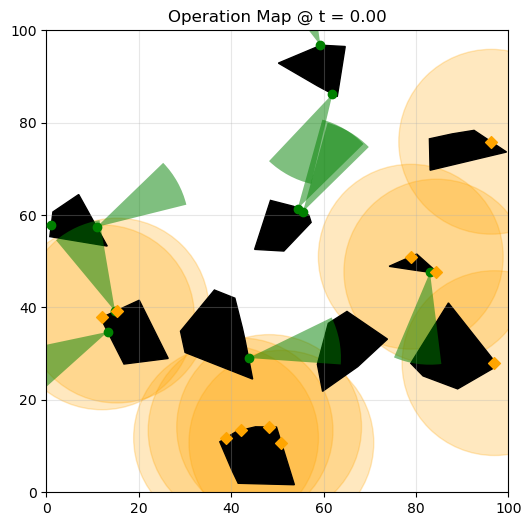

In [4]:
# Generate map*
map_in, cam_dict = generate_map(
    map_size= map_size,
    num_buildings= num_buildings,
    num_directional_sensors= num_direc_sensor,
    num_omni_sensors= num_omni_sensor,
    fov_half_rad= fov_half_rad,
    max_range= max_range,
    fov_half_rad_omni= fov_half_rad,
    max_range_omni= max_range/2,
    panspeed_range= panspeed_range,
    cam_period= cam_period,
    cam_increment= cam_increment,
    rng_seed= rng_seed,
    balanced_sensors= False,
    param_lambda= [0.5, 0.5],
    param_beta= [0.4, 0.25]
)

# Parse map_in dictionary
map_size = map_in['st']['size']

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [ ]:
# Perturbation Setup
sigma_sweep = np.linspace(0, 1, 10)
sigma_nominal_p = max_range
sigma_nominal_w = np.mean(np.abs(
    [cam_dict['directional']['spec']['panspeed'][i] for i in range(cam_dict['n_direc'])]
))

# MAP_SEEDS = [2, 42, 123]
MAP_SEEDS = [4134]
# VMAX_FIXED = 15
J_A_results = {round(s, 2): [] for s in sigma_sweep}

In [ ]:
num_Monte_Carlo = 100
SCENARIO = 'A'

num_success_convergence = 0
defender_cost_history_dict = {}
attacker_cost_history_dict = {}
payoff_history_dict = {}
stopping_criteria_log_dict = {}

for map_seed in MAP_SEEDS:
    map_in, cam_dict = generate_map(
        map_size= (100, 100),
        num_buildings= num_buildings,
        num_directional_sensors= num_direc_sensor,
        num_omni_sensors= num_omni_sensor,
        fov_half_rad= fov_half_rad,
        max_range= max_range,
        fov_half_rad_omni= fov_half_rad,
        max_range_omni= max_range/2,
        panspeed_range= panspeed_range,
        cam_period= cam_period,
        cam_increment= cam_increment,
        rng_seed= 2,
        balanced_sensors= False,
        param_lambda= [0.5, 0.5],
        param_beta= [0.4, 0.25]
    )

    # ── FIX 1: Hoist all map-dependent setup outside sigma/MC loops ──────────

    # Helper function to compute Half-Space parameters for a convex polygon
    # Original code written by Joseph
    def get_polygon_half_space_constraints(poly_vertices: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        A_list, b_list = [], []
        N_verts = len(poly_vertices)
        
        if poly_vertices.ndim == 2:
            centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])
        else:
            raise ValueError("Obstacle data is not a polygon vertex array. Check Cell 3 map setup.")
        
        for i in range(N_verts):
            v1 = poly_vertices[i]
            v2 = poly_vertices[(i + 1) % N_verts]
            
            ex, ey = v2[0] - v1[0], v2[1] - v1[1]
            n1 = np.array([-ey, ex])
            norm_n1 = np.linalg.norm(n1)
            if norm_n1 > 1e-6:
                n1 = n1 / norm_n1

            mid_point = (v1 + v2) / 2.0
            vec_to_centroid = np.array(centroid) - mid_point
            
            if np.dot(n1, vec_to_centroid) < 0:
                a_i = n1
            else:
                a_i = -n1
                
            b_i = np.dot(a_i, v1)
            A_list.append(a_i)
            b_list.append(b_i)

        return np.array(A_list), np.array(b_list)

    # Pre-calculate A and b for all buildings
    obstacle_constraints = []
    for i in range(map_in['st']['n']):
        poly_vertices = map_in['st'][str(i)]
        A, b = get_polygon_half_space_constraints(poly_vertices)
        obstacle_constraints.append({'A': A, 'b': b})

    print(f"Pre-processed {len(obstacle_constraints)} convex polygon obstacles.")
    
    # Camera position parameterization
    cam_x_direc = cam_dict['directional']['x']
    cam_y_direc = cam_dict['directional']['y']
    cam_x_omni = cam_dict['omnidirectional']['x']
    cam_y_omni = cam_dict['omnidirectional']['y']

    # Building param:
    alpha_vec = []
    building_edge_vec = []      # p0,j, start of building edge
    building_vector_vec = []    # ve,j, direction of building edge

    # Find edge of convex polygon with camera:
    def closest_edge(building, cam_xy, tol=None):
        P = np.asarray(building, dtype=float)
        x = np.asarray(cam_xy, dtype=float)
        M = P.shape[0]
        assert M >= 3

        Pn = np.vstack([P, P[0]])
        Ls = np.linalg.norm(Pn[1:] - Pn[:-1], axis=1)
        Lmean = float(np.mean(Ls))
        if tol is None:
            tol = 1e-3 * Lmean if Lmean > 0 else 1e-6

        best = None
        for i in range(M):
            p0_i, p1_i = Pn[i], Pn[i+1]
            v_i = p1_i - p0_i
            L2 = float(v_i @ v_i)
            if L2 < 1e-16:
                continue
            t_raw = float((x - p0_i) @ v_i / L2)
            t_clamped = min(1.0, max(0.0, t_raw))
            proj_i = p0_i + t_clamped * v_i
            d2_i = float(np.sum((x - proj_i)**2))
            if (best is None) or (d2_i < best["d2"]):
                L = np.sqrt(L2)
                t_hat = v_i / L
                n_hat = np.array([-t_hat[1], t_hat[0]])
                best = dict(
                    edge_idx=i, alpha=t_clamped, proj=proj_i, d2=d2_i,
                    tangent=t_hat, normal=n_hat, p0=p0_i, p1=p1_i
                )

        dist = float(np.sqrt(best["d2"])) if best is not None else np.inf
        is_on = bool(dist <= tol)

        vertex_hit = None
        vdist = np.linalg.norm(P - x, axis=1)
        v_idx = int(np.argmin(vdist))
        if float(vdist[v_idx]) <= tol:
            vertex_hit = v_idx

        # *** CRITICAL: compute v_e from best['p1'] and best['p0'], not loop vars ***
        v_e = best["p1"] - best["p0"]

        best.update({
            "is_on_building": is_on,
            "distance": dist,
            "vertex_hit": vertex_hit,
            "tol_used": float(tol),
            "v_e": v_e
        })
        return best

    # Directional Sensor
    for n_building in range(map_in['st']['n']):
        for n_sensor in range(cam_dict['n_direc']):
            pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_direc[n_sensor],cam_y_direc[n_sensor]])
            if pos_sensor_j['is_on_building']:
                alpha_vec.append(pos_sensor_j['alpha'])
                building_edge_vec.append(pos_sensor_j['p0'])
                building_vector_vec.append(pos_sensor_j['v_e'])

    # Omnidirectional Sensor            
    for n_building in range(map_in['st']['n']):
        for n_sensor in range(cam_dict['n_omni']):
            pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_omni[n_sensor], cam_y_omni[n_sensor]])
            if pos_sensor_j['is_on_building']:
                alpha_vec.append(pos_sensor_j['alpha'])
                building_edge_vec.append(pos_sensor_j['p0'])
                building_vector_vec.append(pos_sensor_j['v_e'])
                
    # Elfes model parameters
    alpha_direc = 99/(cam_dict['directional']['spec']['fov'][1]**2)
    alpha_omni = 99/(cam_dict['omnidirectional']['spec']['fov'][1]**2)
    c_param = 10

    def stage_detectability(x, y, t, S, camera_objects):
        """Scalar detectability at a single (x, y, t) point — used by C_AS for defender."""
        k_prod = 1.0
        for cam_i in range(cam_dict['n']):
            dx = x - S[0, cam_i]
            dy = y - S[1, cam_i]
            dist_sq = dx**2 + dy**2
            dist_min_sq = ca.fmax(dist_sq, 1e-4)
            dist_safe = ca.sqrt(dist_min_sq)
            if cam_i < cam_dict['n_direc']:
                cam = camera_objects[cam_i]
                phi = cam.get_ctr_theta_t(t)
                theta = cam.fov_ang
                cos_alpha = (dx*ca.cos(phi) + dy*ca.sin(phi))/dist_safe
                visibility = 1/(1+ca.exp(-c_param*(cos_alpha - ca.cos(theta/2))))
                observability = 1/(1+alpha_direc*dist_min_sq)
            else:
                visibility = 1
                observability = 1/(1+alpha_omni*dist_min_sq)
            k_j = visibility*observability
            k_prod *= (1 - k_j)
        return 1 - k_prod

    def stage_detectability_batch(x_vec, y_vec, t_vec, S, camera_objects):
        """Vectorized detectability for N waypoints simultaneously.
        
        x_vec, y_vec, t_vec: CasADi column vectors of shape (N, 1).
        Returns k_total of shape (N, 1).
        
        get_ctr_theta_t uses ca.sin, so it is fully CasADi-compatible and
        accepts a vector t_vec, reducing graph construction from N*M to M loops.
        """
        N_pts = x_vec.shape[0]
        k_prod = ca.MX.ones(N_pts, 1)
        for cam_i in range(cam_dict['n']):
            dx = x_vec - S[0, cam_i]
            dy = y_vec - S[1, cam_i]
            dist_sq = dx**2 + dy**2
            dist_min_sq = ca.fmax(dist_sq, 1e-4)
            dist_safe = ca.sqrt(dist_min_sq)
            if cam_i < cam_dict['n_direc']:
                cam = camera_objects[cam_i]
                phi = cam.get_ctr_theta_t(t_vec)  # (N, 1) — CasADi-compatible
                theta = cam.fov_ang
                cos_alpha = (dx * ca.cos(phi) + dy * ca.sin(phi)) / dist_safe
                visibility = 1 / (1 + ca.exp(-c_param * (cos_alpha - ca.cos(theta / 2))))
                observability = 1 / (1 + alpha_direc * dist_min_sq)
            else:
                visibility = ca.MX.ones(N_pts, 1)
                observability = 1 / (1 + alpha_omni * dist_min_sq)
            k_j = visibility * observability
            k_prod = k_prod * (1 - k_j)
        return 1 - k_prod

    # Pre-build camera objects once. x0/y0 are stored but not used by
    # get_ctr_theta_t or fov_ang — only cam_dict spec (indexed by i) matters.
    camera_objects = [Camera(i, cam_dict, 0.0, 0.0) for i in range(cam_dict['n_direc'])]

    # Trajectory cost C(A, S) — used for defender and cost evaluation
    M = cam_dict['n']
    n_d = cam_dict['n_direc']

    dt1_vec  = []
    dt2_vec  = []
    lam_vec  = []
    beta_vec = []

    for j in range(M):
        sensor_type = 'directional' if j < n_d else 'omnidirectional'
        dt1_vec.append(cam_dict[sensor_type]['spec']['fov'][1] / 100.0)
        dt2_vec.append(cam_dict[sensor_type]['spec']['fov'][1])
        lam_vec.append(cam_dict['detection'][sensor_type]['param_lambda'])
        beta_vec.append(cam_dict['detection'][sensor_type]['param_beta'])

    dt1_vec  = np.array(dt1_vec, dtype=float)
    dt2_vec  = np.array(dt2_vec, dtype=float)
    lam_vec  = np.array(lam_vec, dtype=float)
    beta_vec = np.array(beta_vec, dtype=float)

    def C_AS(A, S, eps=1e-9):
        N = A.shape[1]
        C = 0
        for i in range(N):
            x_i = A[0, i]
            y_i = A[1, i]
            t_i = A[2, i]
            k_i = stage_detectability(x_i, y_i, t_i, S, camera_objects)
            C += -ca.log(1.0 - k_i + eps)
        return C

    # FIX 3: Compiled cost evaluator — avoids rebuilding CasADi graph on each logging call
    _cost_fn_cache = {}
    def eval_cost(A_np, S_np):
        n = A_np.shape[1]
        if n not in _cost_fn_cache:
            A_s = ca.MX.sym('A', 3, n)
            S_s = ca.MX.sym('S', 2, cam_dict['n'])
            _cost_fn_cache[n] = ca.Function('C_eval', [A_s, S_s], [C_AS(A_s, S_s)])
        return float(_cost_fn_cache[n](A_np, S_np))

    def interpolate_rrt_path_preserve_speed(rrt_path, num_points):
        rrt_array = np.array(rrt_path)
        x = rrt_array[:, 0]
        y = rrt_array[:, 1]
        t = rrt_array[:, 2]

        fx = interp1d(t, x, kind='linear')
        fy = interp1d(t, y, kind='linear')

        t_interp = np.linspace(t[0], t[-1], num_points)
        x_interp = fx(t_interp)
        y_interp = fy(t_interp)

        return x_interp.tolist(), y_interp.tolist(), t_interp.tolist()
    
    # Perturbation Function
    def perturb_positions(S_true, sigma_normalized):
        sigma_p = sigma_normalized * sigma_nominal_p
        noise = np.random.randn(*S_true.shape)*sigma_p
        return S_true + noise
    
    def perturb_schedule(cam_dict_true, sigma_normalized):
        sigma_w = sigma_normalized * sigma_nominal_w
        cam_dict_believed = deepcopy(cam_dict)
        n_direc = cam_dict['n_direc']
        for i in range(n_direc):
            noise = np.random.randn()*sigma_w
            cam_dict_believed['directional']['spec']['panspeed'][i] += noise
        return cam_dict_believed

    # FIX 4: Pre-build defender Opti for standard N_attk+1 path size; reuse across all iterations
    N_attk = 250  # Reduced from 250 — controls attacker NLP size; increase for finer resolution
    N_eval_fixed = N_attk + 1
    total_number_of_sensors = cam_dict['n']
    total_directional_sensors = cam_dict['n_direc']
    total_omnidirectional_sensors = cam_dict['n_omni']

    opti_d_pb = ca.Opti()
    _alpha_j_pb = opti_d_pb.variable(total_number_of_sensors)
    opti_d_pb.subject_to(_alpha_j_pb >= 0)
    opti_d_pb.subject_to(_alpha_j_pb <= 1)
    _Sx_pb = []
    _Sy_pb = []
    for _j in range(total_number_of_sensors):
        _p1 = building_edge_vec[_j]
        _s = _p1 + _alpha_j_pb[_j] * building_vector_vec[_j]
        _Sx_pb.append(_s[0])
        _Sy_pb.append(_s[1])
    _S_pb = ca.vertcat(ca.hcat(_Sx_pb), ca.hcat(_Sy_pb))
    _A_param_pb = opti_d_pb.parameter(3, N_eval_fixed)
    _C_pb = C_AS(_A_param_pb, _S_pb)
    opti_d_pb.minimize(-_C_pb)
    opti_d_pb.solver('ipopt',
        {"expand": True, "verbose": False, "print_time": False},
        {'max_iter': 3000, 'tol': 1e-6, 'acceptable_tol': 1e-4,
         'print_level': 0, "sb": "yes", "print_timing_statistics": "no"})

    def optimize_defender(A_fixed, rho=0.0):
        if A_fixed.shape[1] == N_eval_fixed:
            # Fast path: reuse pre-built NLP, only update parameter
            opti_d_pb.set_value(_A_param_pb, A_fixed)
            opti_d_pb.set_initial(_alpha_j_pb, 0.5 * np.ones(total_number_of_sensors))
            try:
                sol_d = opti_d_pb.solve()
                alpha_star = sol_d.value(_alpha_j_pb)
                S_star = sol_d.value(_S_pb)
                C_star = sol_d.value(_C_pb)
            except RuntimeError as e:
                print('Magos, this machine spirit is tainted:', e)
                alpha_star = opti_d_pb.debug.value(_alpha_j_pb)
                S_star = opti_d_pb.debug.value(_S_pb)
                C_star = opti_d_pb.debug.value(_C_pb)
            return alpha_star, S_star, C_star, sol_d
        else:
            # Fallback: fresh build for non-standard sizes (e.g., initial RRT path)
            opti_d = ca.Opti()
            alpha_j = opti_d.variable(total_number_of_sensors)
            opti_d.subject_to(alpha_j >= 0)
            opti_d.subject_to(alpha_j <= 1)
            Sx = []
            Sy = []
            for j in range(total_number_of_sensors):
                p1 = building_edge_vec[j]
                s = p1 + alpha_j[j] * building_vector_vec[j]
                Sx.append(s[0])
                Sy.append(s[1])
            S = ca.vertcat(ca.hcat(Sx), ca.hcat(Sy))
            N_eval_defender = A_fixed.shape[1]
            A_param = opti_d.parameter(3, N_eval_defender)
            opti_d.set_value(A_param, A_fixed)
            C = C_AS(A_param, S)
            opti_d.minimize(-C)
            opti_d.set_initial(alpha_j, 0.5 * np.ones(total_number_of_sensors))
            opti_d.solver('ipopt',
                {"expand": True, "verbose": False, "print_time": False},
                {'max_iter': 3000, 'tol': 1e-6, 'acceptable_tol': 1e-4,
                 'print_level': 0, "sb": "yes", "print_timing_statistics": "no"})
            try:
                sol_d = opti_d.solve()
                alpha_star = sol_d.value(alpha_j)
                S_star = sol_d.value(S)
                C_star = sol_d.value(C)
            except RuntimeError as e:
                print('Magos, this machine spirit is tainted:', e)
                alpha_star = opti_d.debug.value(alpha_j)
                S_star = opti_d.debug.value(S)
                C_star = opti_d.debug.value(C)
            return alpha_star, S_star, C_star, sol_d

    # FIX 2: Pre-build alpha_init and S_init once per map (depends on building_edge_vec)
    alpha_init_vec = 0.5 * np.ones(M)
    S_init = np.column_stack([
        building_edge_vec[j] + alpha_init_vec[j] * building_vector_vec[j] for j in range(M)
    ])

    # def optimize_attacker(S_fixed, S_star, N=1000, cam_dict_input=None):
    #     start_time = path[0][2]
    #     end_time = path[-1][2]

    #     opti_a = ca.Opti()

    #     T = opti_a.variable()
    #     dt = T/N

    #     opti_a.subject_to(T >= 1e-3)
    #     opti_a.subject_to(T <= end_time*1.5)

    #     x_a = opti_a.variable(N+1)
    #     y_a = opti_a.variable(N+1)

    #     opti_a.subject_to(x_a[0] == x0[0])
    #     opti_a.subject_to(y_a[0] == x0[1])
    #     opti_a.subject_to(x_a[-1] == xf[0])
    #     opti_a.subject_to(y_a[-1] == xf[1])
    #     opti_a.subject_to(opti_a.bounded(map_size[0], x_a, map_size[1]))
    #     opti_a.subject_to(opti_a.bounded(map_size[2], y_a, map_size[3]))

    #     # Vectorized speed constraint — one vector op replaces N scalar constraints
    #     dx = x_a[1:] - x_a[:-1]
    #     dy = y_a[1:] - y_a[:-1]
    #     opti_a.subject_to(dx**2 + dy**2 <= (vmax*dt)**2)
            
    #     S_param = opti_a.parameter(2, cam_dict['n'])
    #     opti_a.set_value(S_param, S_star)

    #     # Initial sensor positions (fixed reference)
    #     S_fixed_param = opti_a.parameter(2, cam_dict['n'])
    #     cam_x = np.hstack((cam_dict['directional']['x'], cam_dict['omnidirectional']['x']))
    #     cam_y = np.hstack((cam_dict['directional']['y'], cam_dict['omnidirectional']['y']))
    #     opti_a.set_value(S_fixed_param, np.vstack((cam_x, cam_y)))
            
    #     gamma = 500
    #     vehicle_radius = 1
    #     buffer_dist = 1
    #     safety_margin = vehicle_radius + buffer_dist

    #     # Vectorized time vector — shape (N, 1), replaces scalar t_i = start + Ni*dt loop
    #     step_idx = ca.DM(np.arange(N).reshape(-1, 1))
    #     t_vec = start_time + step_idx * dt

    #     # Vectorized detectability: M=20 loops over cameras instead of N*M=~2000 loops
    #     k_all = stage_detectability_batch(x_a[:N], y_a[:N], t_vec, S_param, camera_objects)
    #     log_sum = ca.sum1(ca.log(1 - k_all + 1e-9))  # (1,1) scalar

    #     # Vectorized obstacle avoidance: loop over obstacles, vectorized over all N timesteps
    #     P = ca.horzcat(x_a[:N], y_a[:N]).T  # (2, N)
    #     for obs_data in obstacle_constraints:
    #         A_obs    = ca.DM(obs_data['A'])                          # (n_edges, 2)
    #         b_obs    = ca.DM(obs_data['b'].reshape(-1, 1))           # (n_edges, 1)
    #         h_matrix = ca.mtimes(A_obs, P) - ca.repmat(b_obs, 1, N)  # (n_edges, N)
    #         num_edges = obs_data['A'].shape[0]
    #         max_h = h_matrix[0, :]                                   # (1, N)
    #         for idx in range(1, num_edges):
    #             max_h = ca.fmax(max_h, h_matrix[idx, :])
    #         lse_term = max_h + (1.0/gamma) * ca.log(
    #             ca.sum1(ca.exp(gamma * (h_matrix - ca.repmat(max_h, num_edges, 1)))))
    #         lse_debiased = lse_term - (ca.log(num_edges) / gamma)
    #         opti_a.subject_to(lse_debiased.T >= safety_margin)      # N constraints at once
            
    #     # Time penalty to encourage shorter travel time
    #     time_penalty = 0.02*T
    #     J_total_cost = log_sum - time_penalty
    #     opti_a.minimize(-J_total_cost)

    #     # Interpolating RRT initial guess
    #     x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N+1)
    #     opti_a.set_initial(x_a, x_interp)
    #     opti_a.set_initial(y_a, y_interp)
    #     T_init = float(path[-1][2]-path[0][2])
    #     opti_a.set_initial(T, T_init)

    #     w_sym = ca.vertcat(x_a, y_a, T)
    #     log_sum_evaluator      = ca.Function('physical_cost_evaluator', [w_sym, S_param], [log_sum])
    #     penalty_cost_evaluator = ca.Function('penalty_cost_evaluator', [w_sym, S_param], [time_penalty])

    #     w0 = ca.vertcat(x_interp, y_interp, T_init)
    #     initial_log_sum_value      = float(log_sum_evaluator(w0, S_star).full().item())
    #     initial_penalty_cost_value = float(penalty_cost_evaluator(w0, S_star).full().item())
    #     initial_P_non_detection    = np.exp(initial_log_sum_value)
    #     initial_P_detection        = 1 - initial_P_non_detection
    #     initial_total_cost         = initial_log_sum_value - initial_penalty_cost_value

    #     p_opts = {
    #         "expand": True,
    #         "verbose": False,
    #         "print_time": False,
    #     }
    #     s_opts = {
    #         'max_iter': 3000,
    #         'tol': 1e-6,
    #         'acceptable_tol': 1e-4,
    #         'print_level': 0,
    #         "sb": "yes",
    #         "print_timing_statistics": "no",
    #     }

    #     opti_a.solver('ipopt', p_opts, s_opts)

    #     try:
    #         sol_a = opti_a.solve()
    #         x_a_opt = sol_a.value(x_a)
    #         y_a_opt = sol_a.value(y_a)
    #         T_opt = float(sol_a.value(T))
    #         log_sum_opt = sol_a.value(log_sum)
    #     except RuntimeError as e:
    #         print('Magos, this machine spirit is tainted:', e)
    #         x_a_opt = opti_a.debug.value(x_a)
    #         y_a_opt = opti_a.debug.value(y_a)
    #         T_opt = opti_a.debug.value(T)
    #         log_sum_opt = opti_a.debug.value(log_sum)

    #     t_opt_num = np.linspace(start_time, start_time + T_opt, N+1)
    #     A_star = np.vstack((x_a_opt.T, y_a_opt.T, t_opt_num.T))
    #     return A_star
    def optimize_attacker(S_fixed, S_star, N=1000, cam_dict_input=None):
        start_time = path[0][2]
        end_time = path[-1][2]

        opti_a = ca.Opti()
        T = opti_a.variable()
        dt = T/N

        opti_a.subject_to(T >= 1e-3)
        opti_a.subject_to(T <= end_time*1.5)
        x_a = opti_a.variable(N+1)
        y_a = opti_a.variable(N+1)

        opti_a.subject_to(x_a[0] == x0[0])
        opti_a.subject_to(y_a[0] == x0[1])
        opti_a.subject_to(x_a[-1] == xf[0])
        opti_a.subject_to(y_a[-1] == xf[1])
        opti_a.subject_to(opti_a.bounded(map_size[0], x_a, map_size[1]))
        opti_a.subject_to(opti_a.bounded(map_size[2], y_a, map_size[3]))

        dx = x_a[1:] - x_a[:-1]
        dy = y_a[1:] - y_a[:-1]
        opti_a.subject_to(dx**2 + dy**2 <= (vmax*dt)**2)
    
        S_param = opti_a.parameter(2, cam_dict['n'])
        opti_a.set_value(S_param, S_star)
        S_fixed_param = opti_a.parameter(2, cam_dict['n'])
        cam_x = np.hstack((cam_dict['directional']['x'], cam_dict['omnidirectional']['x']))
        cam_y = np.hstack((cam_dict['directional']['y'], cam_dict['omnidirectional']['y']))
        opti_a.set_value(S_fixed_param, np.vstack((cam_x, cam_y)))
    
        gamma = 500
        vehicle_radius = 1
        buffer_dist = 1
        safety_margin = vehicle_radius + buffer_dist

        # FIX 2: reuse pre-built camera_objects when no schedule perturbation
        if cam_dict_input is None:
            _camera_objects = camera_objects
        else:
            _camera_objects = [Camera(i, cam_dict_input, 0.0, 0.0) for i in range(cam_dict_input['n_direc'])]

        step_idx = ca.DM(np.arange(N).reshape(-1, 1))
        t_vec = start_time + step_idx * dt

        k_all = stage_detectability_batch(x_a[:N], y_a[:N], t_vec, S_param, _camera_objects)
        log_sum = ca.sum1(ca.log(1 - k_all + 1e-9))

        P = ca.horzcat(x_a[:N], y_a[:N]).T
        for obs_data in obstacle_constraints:
            A_obs = ca.DM(obs_data['A'])
            b_obs = ca.DM(obs_data['b'].reshape(-1, 1))
            h_matrix = ca.mtimes(A_obs, P) - ca.repmat(b_obs, 1, N)
            num_edges = obs_data['A'].shape[0]
            max_h = h_matrix[0, :]
            for idx in range(1, num_edges):
                max_h = ca.fmax(max_h, h_matrix[idx, :])
            lse_term = max_h + (1.0/gamma) * ca.log(
                ca.sum1(ca.exp(gamma * (h_matrix - ca.repmat(max_h, num_edges, 1)))))
            lse_debiased = lse_term - (ca.log(num_edges) / gamma)
            opti_a.subject_to(lse_debiased.T >= safety_margin)
        time_penalty = 0.02*T
        J_total_cost = log_sum - time_penalty
        opti_a.minimize(-J_total_cost)

        x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N+1)
        opti_a.set_initial(x_a, x_interp)
        opti_a.set_initial(y_a, y_interp)
        T_init = float(path[-1][2]-path[0][2])
        opti_a.set_initial(T, T_init)
        w_sym = ca.vertcat(x_a, y_a, T)
        log_sum_evaluator = ca.Function('physical_cost_evaluator', [w_sym, S_param], [log_sum])
        penalty_cost_evaluator = ca.Function('penalty_cost_evaluator', [w_sym, S_param], [time_penalty])

        w0 = ca.vertcat(x_interp, y_interp, T_init)
        initial_log_sum_value = float(log_sum_evaluator(w0, S_star).full().item())
        initial_penalty_cost_value = float(penalty_cost_evaluator(w0, S_star).full().item())
        initial_P_non_detection = np.exp(initial_log_sum_value)
        initial_P_detection = 1 - initial_P_non_detection
        initial_total_cost = initial_log_sum_value - initial_penalty_cost_value

        p_opts = {
            "expand": True,
            "verbose": False,
            "print_time": False,
        }
        s_opts = {
            'max_iter': 3000,
            'tol': 1e-6,
            'acceptable_tol': 1e-4,
            'print_level': 0,
            "sb": "yes",
            "print_timing_statistics": "no",
        }
        opti_a.solver('ipopt', p_opts, s_opts)

        try:
            sol_a = opti_a.solve()
            x_a_opt = sol_a.value(x_a)
            y_a_opt = sol_a.value(y_a)
            T_opt = float(sol_a.value(T))
            log_sum_opt = sol_a.value(log_sum)
        except RuntimeError as e:
            print('Magos, this machine spirit is tainted:', e)
            x_a_opt = opti_a.debug.value(x_a)
            y_a_opt = opti_a.debug.value(y_a)
            T_opt = opti_a.debug.value(T)
            log_sum_opt = opti_a.debug.value(log_sum)
        t_opt_num = np.linspace(start_time, start_time + T_opt, N+1)
        A_star = np.vstack((x_a_opt.T, y_a_opt.T, t_opt_num.T))
        return A_star

    # ── End of hoisted setup ──────────────────────────────────────────────────

    for sigma in sigma_sweep:
        sigma_key = round(sigma, 2)
        print(f'--map_seed: {map_seed}, sigma: {sigma_key}--')

        # We change attacker position in this case:
        for monteCarlo_iter in range(num_Monte_Carlo):
            # Setup for Attacker Strategy: STP-RRT*
            # x0 = [rn.uniform(0,100), 0, 0]
            x0 = [0, 0, 0]
            xf = [100, 100, 360]
            vmax = rn.uniform(10, 20)
            # vmax = VMAX_FIXED

            stp_rrt_setup = {}
            stp_rrt_setup['x0'] = x0
            stp_rrt_setup['xf'] = xf
            stp_rrt_setup['vmax'] = vmax

            # Generate Dynamic Map
            dmap = DynamicMap(map_in, cam_dict)
            map_in['dy'] = dmap

            # Vehicle Spec
            vehicle = {}
            vehicle['v'] = vmax
            vehicle['radius'] = 1
            
            run_rrt = True
            debug = False
            
            while True:
                # Initialize STP-RRT* Notebook
                rrt_alg = rrt(vmax=vmax, xf=xf, map_size=map_size, vehicle=vehicle, cam_dict=cam_dict, dmap=dmap, max_time=1, map_in=map_in)

                # Run STP-RRT*
                x0 = x0          # start point
                nPartition = 5          # number of trees from the end point
                compTimeLimit = 300     # computation time limit

                min_dist = np.sqrt((x0[0]-xf[0])**2 + (x0[1]-xf[1])**2)
                min_time = min_dist/vmax

                tf0 = min_time                 # lower bound on end time randomization
                tfn = 25                # upper bound on end time randomization

                success_bool, comp_time, total_path_distance, total_path_time, success, path, V_start, V_goal, E_start, E_goal = rrt_alg.standard_Parallel_RRT(x0, nPartition, compTimeLimit, tf0, tfn, debug=debug)
                
                if path is not None:
                    break

            # Save Initial RRT result to a JSON File
            rrt_parameters={
                'success_bool': success_bool,
                'computation_time': comp_time,
                'path_distance': total_path_distance,
                'path_time': total_path_time,
                'path': path,
                'Vstart': V_start,
                'Vgoal': V_goal,
                'Estart': E_start,
                'Egoal': E_goal,
            }

            # Visualize RRT result
            print('Total Cost: '+str(rrt_alg.detection_cost_for_path(path)))
            
            ############################################
            # --- Attacker-Defender Iteration Setup ---
            ############################################
            path_arr = np.array(path)
            A_initial = path_arr.T
            A_prev = A_initial.copy()

            # Param for cycling
            cycle_window = 4
            cycle_tol = 1e-3
            eta_min = 0.05
            eta_decay = 0.5

            eta = 0.3
            rho = 1.0

            max_iters = 50
            tol_alpha = 1e-3
            tol_A = 1e-3
            tol_cost = 1e-4

            print("Initial A shape:", A_initial.shape)
            print("Initial alpha:", alpha_init_vec)
            print("Initial S shape:", S_init.shape)

            # Storage history
            defender_cost_history = []
            attacker_cost_history = []
            payoff_history = []
            alpha_history = []
            A_history = []
            S_history = []
            stopping_criteria_log = {}
            stopping_criteria_log['sensor_shift'] = []
            stopping_criteria_log['cost_shift'] = []
            stopping_criteria_log['eig_val'] = {}
            stopping_criteria_log['eig_val']['eig_A'] = []
            stopping_criteria_log['eig_val']['eig_S'] = []

            # Initialization
            alpha_prev_vec = alpha_init_vec.copy()
            A_prev = A_initial.copy()
            S_prev = S_init.copy()

            J_tot_init = eval_cost(A_initial, S_init)  # FIX 3
            prev_total_cost = 0
            payoff_history.append(J_tot_init)

            # Iteration
            for attacker_defender_iter in range(max_iters):
                alpha_old = alpha_prev_vec.copy()
                A_old = A_prev.copy()
                
                ######################################################################
                # --- Optimize defender strategy given fixed attacker strategy ---
                ######################################################################
                try:
                    alpha_star, S_star, C_defender, sol_d = optimize_defender(A_fixed=A_prev, rho=rho)
                except RuntimeError as e:
                    print('Magos, this machine spirit is tainted:', e)
                    continue
                
                val_def = eval_cost(A_prev, S_star)  # FIX 3
                defender_cost_history.append(val_def)

                #####################################################################
                # --- Optimize attacker strategy given fixed defender strategy ---
                #####################################################################
                try:
                    if SCENARIO == 'A':
                        cam_dict_believed = perturb_schedule(cam_dict, sigma)
                        A_star = optimize_attacker(S_fixed=S_prev, S_star=S_star, N=N_attk, cam_dict_input=cam_dict_believed)
                        # A_star = optimize_attacker(S_fixed=S_prev, S_star=S_star, N=N_attk, cam_dict_input=None)
                    else:
                        S_believed = perturb_positions(S_star, sigma)
                        A_star = optimize_attacker(S_fixed=S_prev, S_star=S_believed, N=N_attk, cam_dict_input=None)
                except RuntimeError as e:
                    print('Magos, this machine spirit is tainted:', e)
                    continue
                
                val_att = eval_cost(A_star, S_prev)  # FIX 3
                attacker_cost_history.append(val_att)
                
                # alpha_history.append(alpha_star.copy())
                # A_history.append(A_star.copy())
                # S_history.append(S_star.copy())

                # S_true = np.vstack((
                #     np.hstack((cam_dict['directional']['x'], cam_dict['omnidirectional']['x'])),
                #     np.hstack((cam_dict['directional']['y'], cam_dict['omnidirectional']['y'])),
                # ))

                # J_A_true = eval_cost(A_star, S_true)  # FIX 3
                # J_A_results[sigma_key].append({
                #     # 'scenario': SCENARIO,
                #     'map_seed': map_seed,
                #     'sigma': sigma_key,
                #     'mc_iter': monteCarlo_iter,
                #     'J_A_true': J_A_true
                # })

                #####################################################################
                #                  --- Update for next iteration ---
                #####################################################################
                val_total = eval_cost(A_star, S_star)  # FIX 3
                payoff_history.append(val_total)
                
                ######################################################################
                #                    --- Stopping criteria ---
                ######################################################################
                current_total_cost = val_total
                cost_diff = abs(current_total_cost - prev_total_cost)
                sensor_shift = np.linalg.norm(S_star - S_prev)

                # Eigenvalue-based KKT check (disabled — re-enable by computing game Jacobian)
                size_A = 3 * (N_attk + 1)
                
                stopping_criteria_log['sensor_shift'].append(sensor_shift)
                stopping_criteria_log['cost_shift'].append(cost_diff)
                
                # Convergence: sensors and costs have stopped changing
                is_stable = (sensor_shift < 1e-3) # and (cost_diff < 1e-4)
                
                if is_stable:
                    equilibrium_type = 'Constrained Local Nash'
                    print('Praise the Omnissiah. Convergence has achieved!')
                    num_success_convergence += 1
                    break
                elif attacker_defender_iter >= max_iters - 1:
                    print('Magos, we have reached for maximum iteration.')
                    break
                else:
                    print('Magos, the machine spirit has failed')
                    prev_total_cost = current_total_cost
                
                A_prev = A_star.copy()
                S_prev = S_star.copy()
            alpha_history.append(alpha_star.copy())
            A_history.append(A_star.copy())
            S_history.append(S_star.copy())

            S_true = np.vstack((
                np.hstack((cam_dict['directional']['x'], cam_dict['omnidirectional']['x'])),
                np.hstack((cam_dict['directional']['y'], cam_dict['omnidirectional']['y'])),
            ))

            J_A_true = eval_cost(A_star, S_true)  # FIX 3
            J_A_results[sigma_key].append({
                # 'scenario': SCENARIO,
                'map_seed': map_seed,
                'sigma': sigma_key,
                'mc_iter': monteCarlo_iter,
                'J_A_true': J_A_true
            })
                
            print('------------------'+'Current Iteration: '+str(monteCarlo_iter)+'------------------')
            print(f'Defender Cost: {val_def: .4f}')
            print(f'Attacker Cost: {val_att: .4f}')
            print(f'Overall Cost: {val_total: .4f}')
                
            defender_cost_history_dict[str(monteCarlo_iter)] = defender_cost_history
            attacker_cost_history_dict[str(monteCarlo_iter)] = attacker_cost_history
            payoff_history_dict[str(monteCarlo_iter)] = payoff_history
            stopping_criteria_log_dict[str(monteCarlo_iter)] = stopping_criteria_log
        print(num_success_convergence)

Pre-processed 10 convex polygon obstacles.
--map_seed: 4134, sigma: 0.0--
STP-RRT* initialized
Total Cost: 0.0
Initial A shape: (3, 9)
Initial alpha: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5]
Initial S shape: (2, 20)
Magos, this machine spirit is tainted: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Infeasible_Problem_Detected'
Magos, the machine spirit has failed
Magos, this machine spirit is tainted: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Infeasible_Problem_Detected'
Magos, the machine spir

In [7]:
result = {}
result['scenario'] = SCENARIO
result['n_success'] = num_success_convergence
result['d_cost'] = defender_cost_history_dict
result['a_cost'] = attacker_cost_history_dict
result['payoff'] = payoff_history_dict
result['stopping_criteria'] = stopping_criteria_log_dict
result['J_A_results'] = J_A_results

with open(str(timestamp)+'_SEGame_MC_Info_Sensitivity.json', 'w') as json_file:
    json.dump(result, json_file, indent=4)